Melting lattice and simulating density 0.8 with 11059 particles...


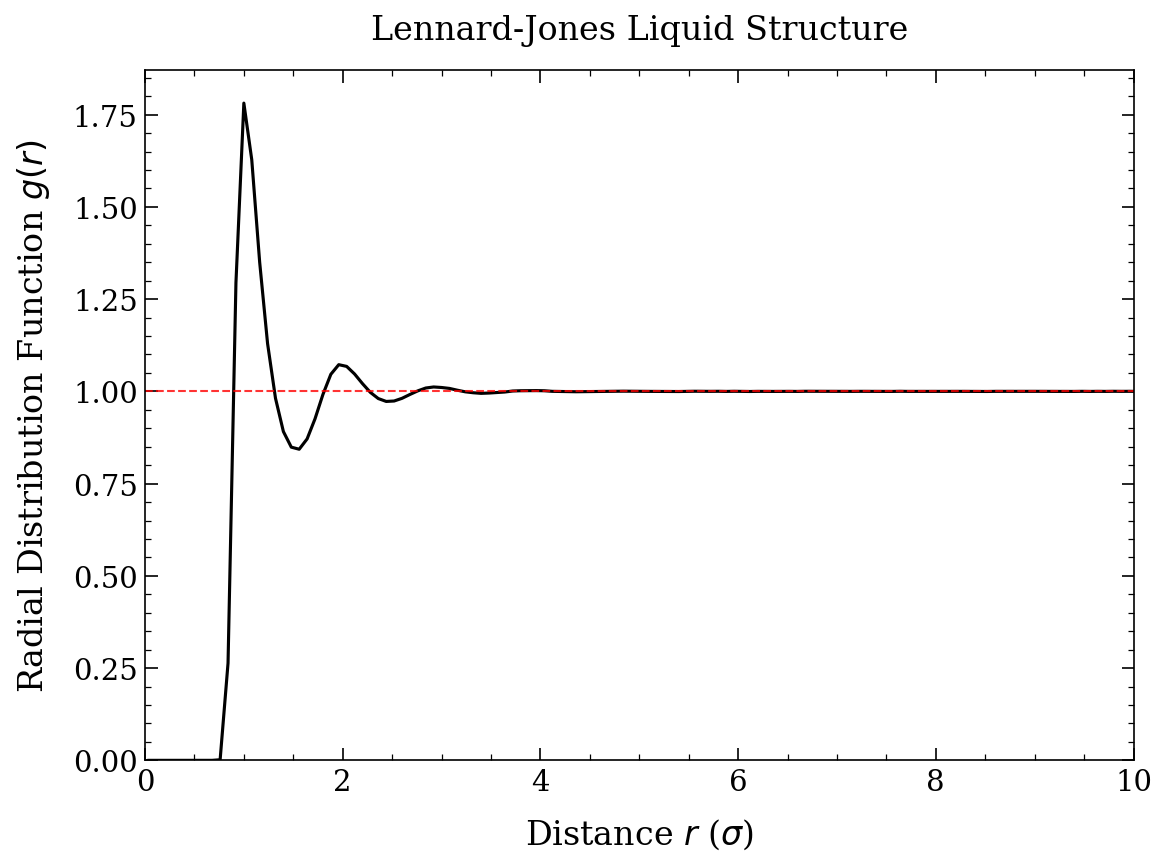

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit

@njit
def fast_lj_rdf_extended(pos, N, L, steps=3000, eq_steps=1000, dt=0.005, rc=2.5):
    vel = np.random.randn(N, 3)

    # Remove net momentum
    v_mean = np.zeros(3)
    for i in range(N):
        v_mean += vel[i]
    v_mean /= N
    for i in range(N):
        vel[i] -= v_mean

    forces = np.zeros((N, 3))

    n_cells_1d = int(L / rc)
    cell_l = L / n_cells_1d
    n_cells = n_cells_1d**3

    # Setup for RDF histogram - Bounded to L/2.0 to see the long-range behavior
    bins = 150 # Increased bins for higher resolution over the larger distance
    hist = np.zeros(bins)
    max_r = L / 2.0
    delg = max_r / bins
    n_samples = 0

    for step in range(steps):
        # 1. Update Positions
        pos = (pos + vel * dt + 0.5 * forces * dt**2) % L

        # 2. Build Linked-Cell List (Used ONLY for forces now)
        head = np.full(n_cells, -1, dtype=np.int32)
        lscl = np.full(N, -1, dtype=np.int32)
        for i in range(N):
            cx = int(pos[i,0]/cell_l) % n_cells_1d
            cy = int(pos[i,1]/cell_l) % n_cells_1d
            cz = int(pos[i,2]/cell_l) % n_cells_1d
            c = cx + cy*n_cells_1d + cz*n_cells_1d**2
            lscl[i] = head[c]
            head[c] = i

        forces_new = np.zeros((N, 3))

        # 3. Compute Forces (Fast loop, limited to rc)
        for cx in range(n_cells_1d):
            for cy in range(n_cells_1d):
                for cz in range(n_cells_1d):
                    c1 = cx + cy*n_cells_1d + cz*n_cells_1d**2
                    i = head[c1]
                    while i != -1:
                        for dx in (-1, 0, 1):
                            for dy in (-1, 0, 1):
                                for dz in (-1, 0, 1):
                                    c2_x = (cx + dx) % n_cells_1d
                                    c2_y = (cy + dy) % n_cells_1d
                                    c2_z = (cz + dz) % n_cells_1d
                                    c2 = c2_x + c2_y*n_cells_1d + c2_z*n_cells_1d**2
                                    j = head[c2]
                                    while j != -1:
                                        if i < j:
                                            dx_p = pos[i,0] - pos[j,0]
                                            dy_p = pos[i,1] - pos[j,1]
                                            dz_p = pos[i,2] - pos[j,2]

                                            dx_p -= L * np.round(dx_p/L)
                                            dy_p -= L * np.round(dy_p/L)
                                            dz_p -= L * np.round(dz_p/L)

                                            r2 = dx_p**2 + dy_p**2 + dz_p**2

                                            if 1e-6 < r2 < rc**2:
                                                r2i = 1.0/r2
                                                r6i = r2i**3
                                                ff = 48.0 * r2i * r6i * (r6i - 0.5)

                                                forces_new[i,0] += ff*dx_p
                                                forces_new[i,1] += ff*dy_p
                                                forces_new[i,2] += ff*dz_p
                                                forces_new[j,0] -= ff*dx_p
                                                forces_new[j,1] -= ff*dy_p
                                                forces_new[j,2] -= ff*dz_p
                                        j = lscl[j]
                        i = lscl[i]

        # 4. Sample RDF (Separate loop, sees up to L/2)
        if step >= eq_steps and step % 10 == 0:
            n_samples += 1
            for i in range(N):
                for j in range(i + 1, N):
                    dx_p = pos[i,0] - pos[j,0]
                    dy_p = pos[i,1] - pos[j,1]
                    dz_p = pos[i,2] - pos[j,2]

                    dx_p -= L * np.round(dx_p/L)
                    dy_p -= L * np.round(dy_p/L)
                    dz_p -= L * np.round(dz_p/L)

                    r2 = dx_p**2 + dy_p**2 + dz_p**2
                    r_mag = np.sqrt(r2)

                    if r_mag < max_r:
                        hist[int(r_mag/delg)] += 2

        # 5. Update Velocities
        if step > 0:
            vel += 0.5 * (forces + forces_new) * dt
        else:
            vel += 0.5 * forces_new * dt

        forces = forces_new

    return hist, delg, n_samples, max_r

# --- Execution ---
L = 24.0  # Box size
density = 0.8
N = int(density * L**3)
steps = 3000
eq_steps = 1000

# RANDOM OVERLAP-FREE INITIALIZATION (only change)
pos = np.zeros((N, 3))
r_min = 0.8
for i in range(N):
    while True:
        trial = np.random.rand(3) * L
        ok = True
        for j in range(i):
            dx = trial[0] - pos[j,0]
            dy = trial[1] - pos[j,1]
            dz = trial[2] - pos[j,2]

            dx -= L * np.round(dx / L)
            dy -= L * np.round(dy / L)
            dz -= L * np.round(dz / L)

            r2 = dx*dx + dy*dy + dz*dz

            if r2 < r_min**2:
                ok = False
                break

        if ok:
            pos[i] = trial
            break

print(f"Melting lattice and simulating density {density} with {N} particles...")
hist, delg, n_samples, max_r = fast_lj_rdf_extended(pos, N, L, steps, eq_steps)

# Normalization over the extended range
r = np.linspace(delg/2, max_r - delg/2, len(hist))
v_shells = (4/3) * np.pi * ((r + delg/2)**3 - (r - delg/2)**3)
rdf = hist / (n_samples * N * density * v_shells)

# --- Professional Plotting (Publication Quality) ---
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 150
})

plt.figure(figsize=(8, 6))

# Main RDF curve
plt.plot(r, rdf, color='black', lw=1.5, label=f'Density: {density}')

# Ideal gas limit line
plt.axhline(1.0, ls='--', color='red', lw=1.0, alpha=0.8)

# Axis formatting
plt.xlabel(r'Distance $r$ ($\sigma$)', labelpad=10)
plt.ylabel(r'Radial Distribution Function $g(r)$', labelpad=10)
plt.title('Lennard-Jones Liquid Structure', pad=15)

# Setting limits and removing internal grid
plt.xlim(0, 10) # Focused on the active structural region instead of max_r
plt.ylim(0, None)

# Professional "Ticks" (Inward facing, present on all sides)
plt.tick_params(direction='in', top=True, right=True, length=6)
plt.minorticks_on()
plt.tick_params(which='minor', direction='in', top=True, right=True, length=3)

# Remove the grid
plt.grid(False)

plt.tight_layout()
plt.show()